
# Módulo 5 — Regularização explícita em Deep Learning

> **Tema:** L1/L2 e weight decay, dropout, label smoothing, max-norm e constraints.  
> **Objetivo didático:** aprender a reduzir overfitting de forma **sistemática**, entendendo o efeito de cada técnica e quando combiná-las.

---

## Roteiro da aula

1. Underfitting vs overfitting (revisão rápida)  
2. L1, L2 e weight decay  
3. Dropout (e variações)  
4. Label smoothing  
5. Penalidades/constraints adicionais (max-norm)  
6. Comparação prática entre estratégias



## 0) Setup

> Este notebook usa **PyTorch** e um dataset sintético (`make_moons`) para treino rápido e foco conceitual.  
> A estratégia será criar um cenário com tendência a overfitting e comparar técnicas de regularização.


In [18]:

# =========================
# Setup e bibliotecas
# =========================
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cpu



## 1) Preparando dados com tendência a overfitting

Aqui usamos **poucos dados de treino** (propositalmente) e uma rede relativamente grande, para aumentar risco de overfitting.


In [19]:

# =====================================
# Dados: make_moons
# =====================================
X, y = make_moons(n_samples=5000, noise=0.30, random_state=SEED)

# Primeiro separa um grande holdout
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

# Agora força treino pequeno (overfitting provável) e validação maior
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.85, random_state=SEED, stratify=y_temp
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

print("Treino:", X_train_t.shape, "Val:", X_val_t.shape, "Teste:", X_test_t.shape)

def make_loaders(batch_size=64):
    train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=256, shuffle=False)
    test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=256, shuffle=False)
    return train_loader, val_loader, test_loader


Treino: torch.Size([600, 2]) Val: torch.Size([3400, 2]) Teste: torch.Size([1000, 2])



## 2) Modelo base

Uma MLP com capacidade relativamente alta para os dados disponíveis.


In [20]:

# =====================================
# Modelo base (com dropout configurável)
# =====================================
class MLP(nn.Module):
    def __init__(self, dropout=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.net(x)



## 3) Funções utilitárias de avaliação

Usaremos:
- **Loss** (BCEWithLogits)
- **Accuracy**
- **F1**
- **AUC**

> Em datasets desbalanceados, F1 e AUC são mais informativas que acurácia isolada.


In [21]:

def evaluate(model, loader):
    model.eval()
    losses, ys, ps = [], [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = F.binary_cross_entropy_with_logits(logits, yb)
            losses.append(loss.item())

            prob = torch.sigmoid(logits)
            ys.append(yb.cpu().numpy())
            ps.append(prob.cpu().numpy())

    y_true = np.vstack(ys).ravel()
    y_prob = np.vstack(ps).ravel()
    y_pred = (y_prob >= 0.5).astype(int)

    return {
        "loss": float(np.mean(losses)),
        "acc": accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "auc": roc_auc_score(y_true, y_prob),
    }



## 4) Componentes de regularização explícita

### 4.1 Label smoothing (binário)
No binário, uma forma simples é deslocar os rótulos para perto de 0.5:

\[
$y_{smooth} = y(1-\epsilon) + 0.5\epsilon$
\]

- reduz excesso de confiança
- melhora robustez em alguns cenários


In [22]:

def smooth_binary_labels(y, eps=0.1):
    # y em {0,1} -> y' no intervalo (eps/2, 1-eps/2)
    return y * (1.0 - eps) + 0.5 * eps



### 4.2 Penalidade L1
Adicionamos ao loss principal:

\[
$L_{total} = L_{task} + \lambda_1 \|\theta\|_1$
\]

Efeito típico:
- induz esparsidade (mais pesos próximos de zero)
- pode ajudar interpretabilidade e compressão


In [23]:

def l1_penalty(model):
    l1 = 0.0
    for p in model.parameters():
        l1 = l1 + p.abs().sum()
    return l1



### 4.3 Max-norm constraint
Após cada `optimizer.step()`, limitamos a norma de cada neurônio (linha da matriz de pesos).

- controla crescimento exagerado de pesos
- pode estabilizar treino e generalização


In [24]:

def apply_max_norm(model, max_norm=3.0):
    with torch.no_grad():
        for module in model.modules():
            if isinstance(module, nn.Linear):
                w = module.weight.data  # [out_features, in_features]
                norms = w.norm(2, dim=1, keepdim=True).clamp(min=1e-8)
                desired = torch.clamp(norms, max=max_norm)
                module.weight.data = w * (desired / norms)


In [25]:
# Experimento 1: Anatomia dos Pesos (L1 vs L2)
# Mostra visualmente como L1 "mata" conexões (Sparsity) enquanto L2 apenas as diminui.

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import interact, FloatSlider, ToggleButtons

def visualize_regularization_impact(reg_type='L2 (Ridge)', strength=0.01):
    # 1. Configuração: Um modelo superdimensionado (muitos pesos inúteis)
    # Tentando ajustar ruído puro para ver como o regularizador trata o excesso
    torch.manual_seed(42)
    input_dim = 50
    model = nn.Linear(input_dim, 1, bias=False) # Apenas pesos w

    # Inicialização uniforme para vermos a evolução
    nn.init.uniform_(model.weight, -1.0, 1.0)

    # Dados dummy (Ruído)
    X = torch.randn(100, input_dim)
    y = torch.randn(100, 1)

    optimizer = optim.SGD(model.parameters(), lr=0.1)
    criterion = nn.MSELoss()

    # 2. Loop de Treino com Regularização Manual
    steps = 200
    for _ in range(steps):
        optimizer.zero_grad()
        output = model(X)
        loss = criterion(output, y)

        # Adicionando a Penalidade
        if reg_type == 'L1 (Lasso)':
            l1_norm = sum(p.abs().sum() for p in model.parameters())
            loss = loss + strength * l1_norm
        elif reg_type == 'L2 (Ridge)':
            l2_norm = sum(p.pow(2).sum() for p in model.parameters())
            # Nota: PyTorch weight_decay faz isso otimizadamente, mas aqui fazemos manual para didática
            loss = loss + strength * l2_norm

        loss.backward()
        optimizer.step()

    # 3. Visualização dos Pesos Finais
    weights = model.weight.detach().numpy().flatten()

    plt.figure(figsize=(12, 5))

    # Histograma
    plt.subplot(1, 2, 1)
    plt.hist(weights, bins=30, color='skyblue', edgecolor='black')
    plt.axvline(0, color='red', linestyle='--')
    plt.title(f"Histograma dos Pesos ({reg_type})")
    plt.xlabel("Valor do Peso")
    plt.ylabel("Contagem")

    # "Código de Barras" dos Pesos (Visualização de Matriz)
    plt.subplot(1, 2, 2)
    plt.imshow(weights.reshape(5, 10), cmap='RdBu', vmin=-1, vmax=1)
    plt.colorbar(label='Valor')
    plt.title("Mapa de Calor dos Pesos")
    plt.axis('off')

    # Cálculo de Esparsidade (Quantos são zero?)
    threshold = 1e-3
    sparsity = np.sum(np.abs(weights) < threshold) / len(weights)

    plt.suptitle(f"Força: {strength} | Esparsidade (Zeros): {sparsity:.1%}", fontsize=14)
    plt.tight_layout()
    plt.show()

print("L1 força pesos a ZERO (Barras brancas no heatmap). Útil para compressão.")
print("L2 força pesos a serem PEQUENOS, mas não zero. Útil para estabilidade.")

interact(visualize_regularization_impact,
         reg_type=ToggleButtons(options=['L1 (Lasso)', 'L2 (Ridge)']),
         strength=FloatSlider(min=0.0, max=1.0, step=0.05, value=0.1));

L1 força pesos a ZERO (Barras brancas no heatmap). Útil para compressão.
L2 força pesos a serem PEQUENOS, mas não zero. Útil para estabilidade.


interactive(children=(ToggleButtons(description='reg_type', options=('L1 (Lasso)', 'L2 (Ridge)'), value='L1 (L…

Este experimento mostra o histograma dos pesos. Com L1, você verá uma barra gigante surgir no zero (o modelo "matando" neurónios inúteis). Isso é a base de compressão de modelos modernos.

Em classificação, CrossEntropy força o modelo a dizer "Tenho 100% de certeza". Isso cria fronteiras de decisão abruptas e overfitting.
Label Smoothing diz: "Tenha 90% de certeza, guarde 10% para dúvida".

**Visualização:** Vamos ver as Probabilidades (Logits).

**Sem LS (0.0):** O modelo empurra as probabilidades para 0.0 e 1.0 (extremas).

**Com LS (0.2):** O modelo mantém as probabilidades mais suaves, criando clusters mais densos e seguros.

In [26]:
# Experimento 3: Efeito do Label Smoothing na Confiança
import torch.nn.functional as F

def visualize_label_smoothing(smoothing=0.0):
    # 1. Criar dados sintéticos (2 classes, 1D para facilitar visualização)
    # Classe 0 centrada em -2, Classe 1 centrada em +2
    n_samples = 200
    X = torch.cat([torch.randn(n_samples, 1) - 2, torch.randn(n_samples, 1) + 2])
    # Labels hard (0 ou 1)
    y_hard = torch.cat([torch.zeros(n_samples), torch.ones(n_samples)]).long()

    # 2. Modelo Linear Simples
    model = nn.Linear(1, 2)
    opt = optim.SGD(model.parameters(), lr=0.1)

    # Custom Loss para simular Label Smoothing no PyTorch < 1.10 (ou didático)
    # Hoje existe LabelSmoothingCrossEntropy, mas faremos manual para entender
    def smoothed_loss(preds, targets, alpha):
        num_classes = preds.size(1)
        # Cria labels suavizados (ex: 0 vira 0.1, 1 vira 0.9 para 2 classes)
        with torch.no_grad():
            smooth_targets = torch.zeros_like(preds).scatter_(1, targets.unsqueeze(1), 1)
            smooth_targets = smooth_targets * (1 - alpha) + alpha / num_classes

        log_preds = F.log_softmax(preds, dim=1)
        return -(smooth_targets * log_preds).sum(dim=1).mean()

    # Treino
    for _ in range(100):
        opt.zero_grad()
        out = model(X)
        loss = smoothed_loss(out, y_hard, smoothing)
        loss.backward()
        opt.step()

    # 3. Visualizar as Probabilidades Preditas
    X_test = torch.linspace(-6, 6, 100).unsqueeze(1)
    with torch.no_grad():
        probs = F.softmax(model(X_test), dim=1)[:, 1] # Prob da classe 1

    plt.figure(figsize=(10, 5))

    # Plot da Sigmoide de Decisão
    plt.plot(X_test.numpy(), probs.numpy(), linewidth=3, color='purple', label='Probabilidade Modelo')

    # Plot dos Dados
    plt.scatter(X[:n_samples], np.zeros(n_samples), c='red', alpha=0.5, label='Classe 0')
    plt.scatter(X[n_samples:], np.ones(n_samples), c='blue', alpha=0.5, label='Classe 1')

    plt.title(f"Curva de Confiança (Label Smoothing: {smoothing})")
    plt.xlabel("Input Feature")
    plt.ylabel("Probabilidade Estimada (Classe 1)")

    # Visualizar "Overconfidence"
    max_conf = probs.max().item()
    min_conf = probs.min().item()

    if smoothing == 0:
        plt.text(-5, 0.5, "Curva Íngreme!\n(Overconfident)", color='red', fontweight='bold')
    else:
        plt.text(-5, 0.5, "Curva Suave\n(Calibrado)", color='green', fontweight='bold')

    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

print("🍦 Label Smoothing impede que o modelo tenha 100% de certeza (probabilidade 1.0 ou 0.0).")
print("Isso evita que os pesos cresçam ao infinito e melhora a generalização.")
interact(visualize_label_smoothing,
         smoothing=FloatSlider(min=0.0, max=0.5, step=0.1, value=0.0));

🍦 Label Smoothing impede que o modelo tenha 100% de certeza (probabilidade 1.0 ou 0.0).
Isso evita que os pesos cresçam ao infinito e melhora a generalização.


interactive(children=(FloatSlider(value=0.0, description='smoothing', max=0.5), Output()), _dom_classes=('widg…

In [ ]:
# Experimento Visual: A Mecânica do Dropout
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import interact, FloatSlider, IntSlider
from sklearn.datasets import make_moons

def visualize_dropout_mechanics(dropout_rate=0.5, epoch_snapshot=10):
    # 1. Configuração dos Dados
    X_np, y_np = make_moons(n_samples=200, noise=0.3, random_state=42)
    X = torch.FloatTensor(X_np)
    y = torch.FloatTensor(y_np).unsqueeze(1)

    # 2. Configuração da Rede
    hidden_size = 100
    torch.manual_seed(42)
    layer1 = nn.Linear(2, hidden_size)
    layer2 = nn.Linear(hidden_size, 1)
    activation = nn.ReLU()

    optimizer = optim.Adam(list(layer1.parameters()) + list(layer2.parameters()), lr=0.05)
    criterion = nn.BCEWithLogitsLoss()

    mask_visual = None

    # 3. Loop de Treino
    for epoch in range(500):
        optimizer.zero_grad()

        # Passo 1: Linear + Ativação
        h = activation(layer1(X))

        # Passo 2: Aplicar Máscara de Dropout
        if dropout_rate > 0:
            mask = (torch.rand_like(h) > dropout_rate).float()
            mask = mask / (1.0 - dropout_rate) # Inverted Dropout
        else:
            mask = torch.ones_like(h)

        mask_visual = mask[0:20].detach().numpy() # Salva máscara para plot

        # Passo 3: Multiplicar
        h_dropped = h * mask

        # Passo 4: Saída
        out = layer2(h_dropped)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        if epoch == epoch_snapshot:
            break

    # 4. Visualização
    fig = plt.figure(figsize=(14, 6))

    # --- Painel Esquerdo: O "Raio-X" ---
    ax1 = plt.subplot(1, 2, 1)
    # vmin=0 e vmax=2 garantem que Branco=Ativo e Preto=Morto
    im = ax1.imshow(mask_visual.T, cmap='gray', aspect='auto', interpolation='nearest', vmin=0, vmax=2)
    ax1.set_title(f"Raio-X da Camada Oculta (Taxa: {dropout_rate})\nBranco = Ativo | Preto = Morto", fontsize=11)
    ax1.set_ylabel(f"Neurônios (0 a {hidden_size})")
    ax1.set_xlabel("Amostras do Batch (0 a 20)")

    # --- Painel Direito: Fronteira de Decisão ---
    ax2 = plt.subplot(1, 2, 2)

    def predict_eval(x_input):
        h = activation(layer1(x_input))
        return torch.sigmoid(layer2(h))

    xx, yy = np.meshgrid(np.linspace(-2, 3, 100), np.linspace(-1.5, 2, 100))
    grid = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()])
    with torch.no_grad():
        preds = predict_eval(grid).reshape(xx.shape)

    # Plotar o fundo (Fronteira)
    ax2.contourf(xx, yy, preds, levels=20, cmap='RdBu', alpha=0.6)

    # Forçamos a cor baseada na classe: 0 -> Vermelho, 1 -> Azul
    point_colors = np.where(y_np == 0, 'red', 'blue')
    ax2.scatter(X_np[:, 0], X_np[:, 1], c=point_colors, edgecolors='white', s=40, linewidth=1)

    status = "Sem Dropout" if dropout_rate == 0 else f"Dropout Ativo ({dropout_rate})"
    ax2.set_title(f"Resultado: {status}", fontweight='bold')

    plt.tight_layout()
    plt.show()

interact(visualize_dropout_mechanics,
         dropout_rate=FloatSlider(min=0.0, max=0.9, step=0.1, value=0.5, description='Taxa Dropout'),
         epoch_snapshot=IntSlider(min=10, max=400, step=50, value=200, description='Épocas'));

interactive(children=(FloatSlider(value=0.5, description='Taxa Dropout', max=0.9), IntSlider(value=200, descri…

**O Painel da Esquerda (Matrix):**

* Mova o slider dropout_rate para 0.0. A matriz fica toda branca (todos os neurônios funcionam).

* Mova para 0.5. Metade da matriz fica preta. Isso é literal: a cada passo de treino, metade do "cérebro" da rede é desligado aleatoriamente.

* Analogia: "É como tentar aprender a tocar piano, mas a cada aula o professor amarra dedos diferentes da sua mão. Você é obrigado a aprender a tocar a música de forma que qualquer combinação de dedos funcione."

**O Painel da Direita (Decisão):**

* Com 0.0 (Sem Dropout): A fronteira (azul/vermelha) tenta abraçar cada pontinho de ruído. Ela é cheia de "ilhas" e curvas estranhas (Overfitting).

* Com 0.5 (Dropout Ideal): A fronteira ignora o ruído e faz uma curva suave. Por quê? Porque nenhuma "panelinha" de neurônios conseguiu decorar o ruído, já que eles estavam sempre sendo desligados. O modelo aprendeu apenas o padrão forte que sobreviveu ao caos.


## 5) Loop de treino com opções de regularização

Parâmetros principais:
- `weight_decay` (L2/decay no otimizador)
- `dropout`
- `label_smoothing_eps`
- `l1_lambda`
- `use_max_norm`


In [28]:

def train_model(
    epochs=60,
    lr=1e-3,
    batch_size=64,
    dropout=0.0,
    weight_decay=0.0,
    label_smoothing_eps=0.0,
    l1_lambda=0.0,
    use_max_norm=False,
    max_norm_value=3.0,
):
    torch.manual_seed(SEED)
    model = MLP(dropout=dropout).to(device)
    train_loader, val_loader, test_loader = make_loaders(batch_size)

    # AdamW para manter regularização desacoplada quando weight_decay > 0
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_f1": [],
        "val_auc": [],
        "lr": []
    }

    for epoch in range(epochs):
        model.train()
        batch_losses = []

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            # Label smoothing no alvo, se ativado
            y_target = smooth_binary_labels(yb, label_smoothing_eps) if label_smoothing_eps > 0 else yb

            optimizer.zero_grad()
            logits = model(xb)
            loss = F.binary_cross_entropy_with_logits(logits, y_target)

            # Penalidade L1 explícita
            if l1_lambda > 0:
                loss = loss + l1_lambda * l1_penalty(model)

            loss.backward()
            optimizer.step()

            # Max-norm como constraint pós-update
            if use_max_norm:
                apply_max_norm(model, max_norm=max_norm_value)

            batch_losses.append(loss.item())

        train_loss = float(np.mean(batch_losses))
        val_metrics = evaluate(model, val_loader)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_metrics["loss"])
        history["val_f1"].append(val_metrics["f1"])
        history["val_auc"].append(val_metrics["auc"])
        history["lr"].append(optimizer.param_groups[0]["lr"])

    test_metrics = evaluate(model, test_loader)
    return model, history, test_metrics



## 6) Experimento comparativo

Vamos comparar:
1. Baseline (sem regularização)
2. Weight decay
3. Dropout
4. Label smoothing
5. L1
6. Max-norm
7. Combinação (dropout + weight decay + label smoothing)


In [29]:

experiments = {
    "baseline": dict(dropout=0.0, weight_decay=0.0, label_smoothing_eps=0.0, l1_lambda=0.0, use_max_norm=False),
    "weight_decay": dict(dropout=0.0, weight_decay=1e-2, label_smoothing_eps=0.0, l1_lambda=0.0, use_max_norm=False),
    "dropout": dict(dropout=0.30, weight_decay=0.0, label_smoothing_eps=0.0, l1_lambda=0.0, use_max_norm=False),
    "label_smoothing": dict(dropout=0.0, weight_decay=0.0, label_smoothing_eps=0.10, l1_lambda=0.0, use_max_norm=False),
    "l1": dict(dropout=0.0, weight_decay=0.0, label_smoothing_eps=0.0, l1_lambda=1e-6, use_max_norm=False),
    "max_norm": dict(dropout=0.0, weight_decay=0.0, label_smoothing_eps=0.0, l1_lambda=0.0, use_max_norm=True, max_norm_value=3.0),
    "combo": dict(dropout=0.20, weight_decay=5e-3, label_smoothing_eps=0.05, l1_lambda=0.0, use_max_norm=False),
}

histories = {}
trained_models = {}
results_test = {}

for name, cfg in experiments.items():
    model, hist, test_metrics = train_model(
        epochs=60,
        lr=1e-3,
        batch_size=64,
        **cfg
    )
    histories[name] = hist
    trained_models[name] = model
    results_test[name] = test_metrics
    print(f"{name:15s} | Test Loss: {test_metrics['loss']:.4f} | Test F1: {test_metrics['f1']:.3f} | Test AUC: {test_metrics['auc']:.3f}")


baseline        | Test Loss: 0.2309 | Test F1: 0.902 | Test AUC: 0.971
weight_decay    | Test Loss: 0.2306 | Test F1: 0.903 | Test AUC: 0.971
dropout         | Test Loss: 0.2226 | Test F1: 0.908 | Test AUC: 0.972
label_smoothing | Test Loss: 0.2284 | Test F1: 0.907 | Test AUC: 0.972
l1              | Test Loss: 0.2349 | Test F1: 0.904 | Test AUC: 0.971
max_norm        | Test Loss: 0.2309 | Test F1: 0.902 | Test AUC: 0.971
combo           | Test Loss: 0.2152 | Test F1: 0.906 | Test AUC: 0.973


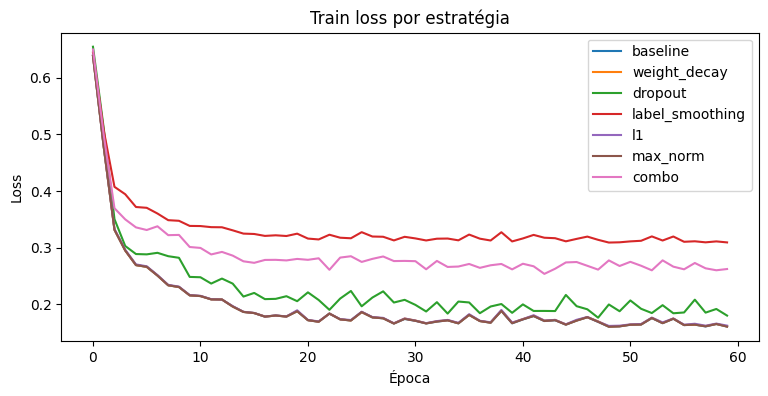

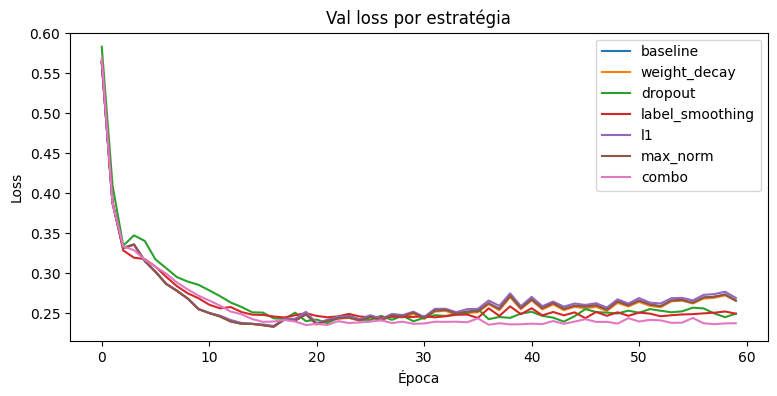

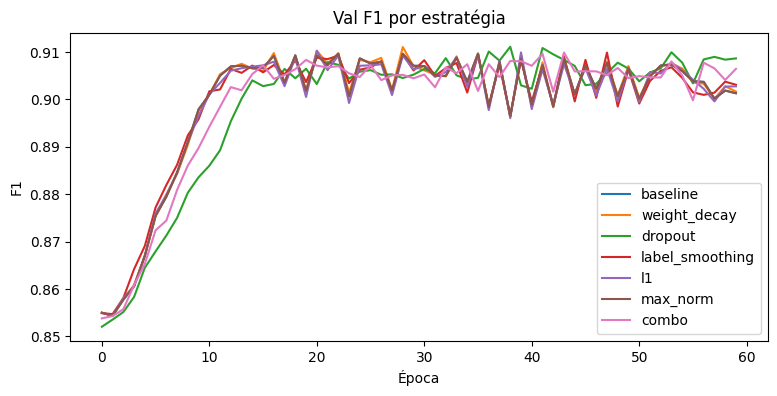

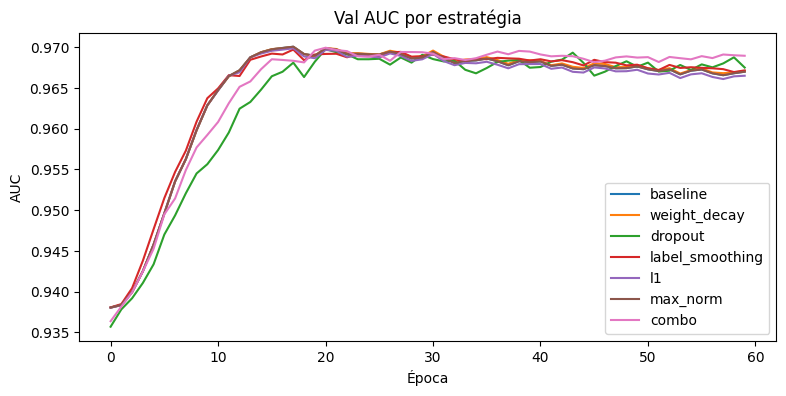

In [30]:

def plot_metric(histories, key, title, ylabel):
    plt.figure(figsize=(9,4))
    for name, h in histories.items():
        plt.plot(h[key], label=name)
    plt.title(title)
    plt.xlabel("Época")
    plt.ylabel(ylabel)
    plt.legend()
    plt.show()

plot_metric(histories, "train_loss", "Train loss por estratégia", "Loss")
plot_metric(histories, "val_loss", "Val loss por estratégia", "Loss")
plot_metric(histories, "val_f1", "Val F1 por estratégia", "F1")
plot_metric(histories, "val_auc", "Val AUC por estratégia", "AUC")



### Leitura didática esperada
- **Baseline**: tende a overfitting (train loss cai muito, val piora/estagna).
- **Weight decay/Dropout**: normalmente reduzem gap treino-validação.
- **Label smoothing**: reduz overconfidence, pode melhorar robustez.
- **L1**: pode melhorar generalização em alguns casos e promove esparsidade.
- **Max-norm**: controla amplitude dos pesos, útil em arquiteturas com tendência a pesos grandes.
- **Combinações** costumam funcionar melhor que técnica isolada (com tuning adequado).



## 7) Medindo esparsidade para L1

Vamos comparar a fração de pesos “quase zero” em:
- baseline
- modelo com L1


In [31]:

def sparsity_ratio(model, threshold=1e-3):
    total = 0
    near_zero = 0
    with torch.no_grad():
        for p in model.parameters():
            arr = p.detach().abs().view(-1)
            total += arr.numel()
            near_zero += (arr < threshold).sum().item()
    return near_zero / total

sp_base = sparsity_ratio(trained_models["baseline"], threshold=1e-3)
sp_l1 = sparsity_ratio(trained_models["l1"], threshold=1e-3)

print(f"Esparsidade (baseline): {sp_base:.3f}")
print(f"Esparsidade (L1):       {sp_l1:.3f}")


Esparsidade (baseline): 0.010
Esparsidade (L1):       0.169



## 8) L2 vs weight decay: nota prática importante

- Em **SGD clássico**, L2 no loss e weight decay podem ser equivalentes em algumas formulações.
- Em otimizadores adaptativos (Adam), essa equivalência deixa de ser “limpa”.
- Por isso, no ecossistema moderno, **AdamW** (decoupled weight decay) é geralmente preferido.

> Regra de bolso: se estiver usando família Adam, comece por **AdamW**.



## 9) Dropout em outros contextos (rápido)

- `nn.Dropout(p)` -> MLP / camadas densas  
- `nn.Dropout2d(p)` -> CNN (zera canais inteiros, regularização espacial)  
- `nn.Dropout1d(p)` / `nn.Dropout3d(p)` conforme o tipo de dado  

### Exemplo CNN curto (referência):
```python
self.features = nn.Sequential(
    nn.Conv2d(3, 32, 3, padding=1),
    nn.ReLU(),
    nn.Dropout2d(0.2),
    nn.Conv2d(32, 64, 3, padding=1),
    nn.ReLU(),
    nn.Dropout2d(0.2),
)
```


Aqui vamos além do "Dropout evita overfitting". Vamos mostrar o MC Dropout.
Em vez de desligar o Dropout no teste (padrão), mantemos ele ligado e fazemos 20 previsões. A variação entre elas nos diz **"O quanto o modelo está confuso"**.

Visual: Onde os pontos de dados existem, o modelo concorda (cor sólida). Onde não existem dados, o modelo "vibra" (sombra difusa). Isso é essencial para carros autônomos (saber quando não sabem).

In [32]:
# Experimento 2: Dropout como Estimador de Incerteza (MC Dropout)

def visualize_mc_dropout(dropout_rate=0.5):
    # 1. Dados: Regressão não-linear com buracos
    np.random.seed(0)
    X = np.sort(np.random.rand(40) * 5)     # Região 0 a 5
    X = np.concatenate([X, X + 10])         # Região 10 a 15 (Buraco entre 5 e 10)
    y = np.sin(X) + np.random.normal(0, 0.1, X.shape)

    X_t = torch.FloatTensor(X).unsqueeze(1)
    y_t = torch.FloatTensor(y).unsqueeze(1)

    # 2. Modelo com Dropout
    # Dica SOTA: Dropout é mantido ATIVO durante a inferência
    class MCDropoutNet(nn.Module):
        def __init__(self, p):
            super().__init__()
            self.fc1 = nn.Linear(1, 64)
            self.fc2 = nn.Linear(64, 64)
            self.out = nn.Linear(64, 1)
            self.drop = nn.Dropout(p=p)
            self.relu = nn.ReLU()

        def forward(self, x):
            x = self.relu(self.drop(self.fc1(x)))
            x = self.relu(self.drop(self.fc2(x)))
            return self.out(x)

    model = MCDropoutNet(p=dropout_rate)
    opt = optim.Adam(model.parameters(), lr=0.01)
    loss_fn = nn.MSELoss()

    # Treino rápido
    model.train()
    for _ in range(500):
        opt.zero_grad()
        l = loss_fn(model(X_t), y_t)
        l.backward()
        opt.step()

    # 3. Inferência Estocástica (Monte Carlo)
    # Gerar grid de teste cobrindo a área SEM dados (5 a 10)
    X_test = np.linspace(-2, 17, 200)
    X_test_t = torch.FloatTensor(X_test).unsqueeze(1)

    # IMPORTANTE: model.train() mantém dropout ligado para simular incerteza
    model.train()
    predictions = []
    for _ in range(50): # 50 passagens
        with torch.no_grad():
            predictions.append(model(X_test_t).numpy().flatten())

    predictions = np.array(predictions)
    mean_pred = predictions.mean(axis=0)
    std_pred = predictions.std(axis=0) # Incerteza (Epistêmica)

    # 4. Plot
    plt.figure(figsize=(10, 6))
    plt.scatter(X, y, c='black', label='Dados Reais', zorder=5)

    # Linha Média
    plt.plot(X_test, mean_pred, c='blue', linewidth=2, label='Previsão Média')

    # Intervalo de Confiança (Incerteza)
    plt.fill_between(X_test, mean_pred - 2*std_pred, mean_pred + 2*std_pred,
                     color='blue', alpha=0.3, label='Incerteza (MC Dropout)')

    plt.title(f"Visualizando o 'Medo' do Modelo (Rate: {dropout_rate})")
    plt.xlabel("Input X"); plt.ylabel("Output Y")
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Highlight na região sem dados
    plt.axvspan(5, 10, color='red', alpha=0.1)
    plt.text(7.5, 0, "Região Sem Dados\n(Alta Incerteza)", ha='center', color='red')

    plt.show()

print("Com MC Dropout, a sombra azul mostra onde o modelo 'não sabe'.")
print("Note como a sombra explode na área vermelha (onde ele nunca viu dados).")
interact(visualize_mc_dropout,
         dropout_rate=FloatSlider(min=0.0, max=0.5, step=0.05, value=0.2));

Com MC Dropout, a sombra azul mostra onde o modelo 'não sabe'.
Note como a sombra explode na área vermelha (onde ele nunca viu dados).


interactive(children=(FloatSlider(value=0.2, description='dropout_rate', max=0.5, step=0.05), Output()), _dom_…


## 10) Guia prático de escolha (rápido para sala)

1. **Primeiro ajuste LR e scheduler** (sem isso, regularização não “salva” treino ruim).  
2. Comece com:
   - `AdamW`
   - `weight_decay` entre `1e-4` e `1e-2`
   - `dropout` entre `0.1` e `0.4` (em MLP/CNN)  
3. Se modelo muito confiante: testar `label_smoothing` (`0.05` a `0.1`).  
4. Se quiser esparsidade/compressão: adicionar L1 pequeno (`1e-7` a `1e-5`).  
5. Se pesos explodem/crescem demais: testar `max-norm`.
6. Weight Decay vs. L2 em Adam: Em SGD, L2 e Weight Decay são a mesma coisa matematicamente. Em Adam, eles não são! Sempre use o parâmetro weight_decay do otimizador AdamW, nunca adicione a perda L2 manualmente na loss, pois interfere na adaptação do gradiente.
7. Dropout em CNNs? Quase não se usa mais Dropout nas camadas convolucionais (pois atrapalha a correlação espacial). Use Batch Normalization que já tem um efeito regularizador natural. Dropout hoje é focado nas camadas finais (Dense/Linear) ou em Transformers (Attention Dropout).
8. Data Augmentation é a Melhor Regularização: Antes de tunar L1/L2, aumente seus dados. CutMix e MixUp (misturar imagens e labels) são técnicas SOTA que funcionam melhor que qualquer ajuste de weight decay.



## 11) Exercícios sugeridos

1. Repetir experimento com 3 seeds e reportar média ± desvio de F1/AUC.  
2. Fazer busca de hiperparâmetros para `dropout` e `weight_decay`.  
3. Comparar `Adam` vs `AdamW` mantendo todos os demais parâmetros fixos.  
4. Adicionar **early stopping** e verificar efeito no overfitting.  
5. Criar um cenário com rótulos ruidosos e medir o impacto de label smoothing.


### Exercício 1

In [33]:
import copy
import itertools

def train_model_extended(
    epochs=60,
    lr=1e-3,
    batch_size=64,
    dropout=0.0,
    weight_decay=0.0,
    label_smoothing_eps=0.0,
    l1_lambda=0.0,
    use_max_norm=False,
    max_norm_value=3.0,
    optimizer_name="adamw",
    seed=42,
    early_stopping_patience=None,
    train_loader_override=None,
):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    model = MLP(dropout=dropout).to(device)
    train_loader, val_loader, test_loader = make_loaders(batch_size)
    if train_loader_override is not None:
        train_loader = train_loader_override

    if optimizer_name.lower() == "adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_name.lower() == "adamw":
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    else:
        raise ValueError("optimizer_name deve ser 'adam' ou 'adamw'")

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_f1": [],
        "val_auc": [],
    }

    best_state = None
    best_val_loss = float("inf")
    epochs_without_improvement = 0
    stopped_epoch = epochs

    for epoch in range(epochs):
        model.train()
        batch_losses = []

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            y_target = smooth_binary_labels(yb, label_smoothing_eps) if label_smoothing_eps > 0 else yb

            optimizer.zero_grad()
            logits = model(xb)
            loss = F.binary_cross_entropy_with_logits(logits, y_target)

            if l1_lambda > 0:
                loss = loss + l1_lambda * l1_penalty(model)

            loss.backward()
            optimizer.step()

            if use_max_norm:
                apply_max_norm(model, max_norm=max_norm_value)

            batch_losses.append(loss.item())

        train_loss = float(np.mean(batch_losses))
        val_metrics = evaluate(model, val_loader)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_metrics["loss"])
        history["val_f1"].append(val_metrics["f1"])
        history["val_auc"].append(val_metrics["auc"])

        if early_stopping_patience is not None:
            if val_metrics["loss"] < best_val_loss - 1e-6:
                best_val_loss = val_metrics["loss"]
                best_state = copy.deepcopy(model.state_dict())
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += 1

            if epochs_without_improvement >= early_stopping_patience:
                stopped_epoch = epoch + 1
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    test_metrics = evaluate(model, test_loader)
    return model, history, test_metrics, stopped_epoch


def summarize_metric(values):
    arr = np.array(values, dtype=np.float32)
    return arr.mean(), arr.std(ddof=1) if len(arr) > 1 else 0.0

In [34]:
# 3 seeds -> média ± desvio de F1/AUC

seed_list = [42, 123, 999]
cfg_seed = dict(dropout=0.20, weight_decay=5e-3, label_smoothing_eps=0.05, l1_lambda=0.0, use_max_norm=False)

seed_results = []
for s in seed_list:
    _, _, tm, _ = train_model_extended(epochs=40, seed=s, optimizer_name="adamw", **cfg_seed)
    seed_results.append(tm)

f1_values = [r["f1"] for r in seed_results]
auc_values = [r["auc"] for r in seed_results]
f1_mean, f1_std = summarize_metric(f1_values)
auc_mean, auc_std = summarize_metric(auc_values)

print("Exercício 1 - 3 seeds (AdamW + combo):")
print(f"F1  = {f1_mean:.4f} ± {f1_std:.4f}")
print(f"AUC = {auc_mean:.4f} ± {auc_std:.4f}")

Exercício 1 - 3 seeds (AdamW + combo):
F1  = 0.9073 ± 0.0045
AUC = 0.9738 ± 0.0005


### Exercício 2


In [35]:
dropout_grid = [0.0, 0.2, 0.4]
weight_decay_grid = [0.0, 1e-4, 1e-3, 1e-2]

search_rows = []
for d, wd in itertools.product(dropout_grid, weight_decay_grid):
    _, hist, tm, _ = train_model_extended(
        epochs=35,
        seed=42,
        optimizer_name="adamw",
        dropout=d,
        weight_decay=wd,
        label_smoothing_eps=0.0,
        l1_lambda=0.0,
        use_max_norm=False,
    )
    search_rows.append({
        "dropout": d,
        "weight_decay": wd,
        "val_auc_last": hist["val_auc"][-1],
        "val_f1_last": hist["val_f1"][-1],
        "test_auc": tm["auc"],
        "test_f1": tm["f1"],
    })

search_rows = sorted(search_rows, key=lambda r: (r["val_auc_last"], r["val_f1_last"]), reverse=True)
best_cfg = search_rows[0]
print("\nExercício 2 - melhor configuração encontrada (por val AUC/F1):")
print(best_cfg)



Exercício 2 - melhor configuração encontrada (por val AUC/F1):
{'dropout': 0.0, 'weight_decay': 0.01, 'val_auc_last': 0.9685529411764707, 'val_f1_last': 0.9033989266547406, 'test_auc': 0.9732919999999999, 'test_f1': 0.9067201604814443}


### Exercício 3

In [36]:
fixed_cfg = dict(
    dropout=best_cfg["dropout"],
    weight_decay=best_cfg["weight_decay"],
    label_smoothing_eps=0.0,
    l1_lambda=0.0,
    use_max_norm=False,
)

_, _, tm_adam, _ = train_model_extended(epochs=40, seed=42, optimizer_name="adam", **fixed_cfg)
_, _, tm_adamw, _ = train_model_extended(epochs=40, seed=42, optimizer_name="adamw", **fixed_cfg)

print("\nExercício 3 - Adam vs AdamW (mesmo setup):")
print(f"Adam  -> F1: {tm_adam['f1']:.4f} | AUC: {tm_adam['auc']:.4f}")
print(f"AdamW -> F1: {tm_adamw['f1']:.4f} | AUC: {tm_adamw['auc']:.4f}")


Exercício 3 - Adam vs AdamW (mesmo setup):
Adam  -> F1: 0.9009 | AUC: 0.9714
AdamW -> F1: 0.9132 | AUC: 0.9731


### Exercício 4

In [37]:
_, hist_no_es, tm_no_es, stop_no_es = train_model_extended(
    epochs=120,
    seed=42,
    optimizer_name="adamw",
    early_stopping_patience=None,
    **fixed_cfg,
)

_, hist_es, tm_es, stop_es = train_model_extended(
    epochs=120,
    seed=42,
    optimizer_name="adamw",
    early_stopping_patience=10,
    **fixed_cfg,
)

print("\nExercício 4 - efeito do Early Stopping:")
print(f"Sem ES -> épocas: {stop_no_es} | Test F1: {tm_no_es['f1']:.4f} | Test AUC: {tm_no_es['auc']:.4f}")
print(f"Com ES -> parada em época: {stop_es} | Test F1: {tm_es['f1']:.4f} | Test AUC: {tm_es['auc']:.4f}")


Exercício 4 - efeito do Early Stopping:
Sem ES -> épocas: 120 | Test F1: 0.9053 | Test AUC: 0.9697
Com ES -> parada em época: 27 | Test F1: 0.9138 | Test AUC: 0.9752


### Exercício 5

In [38]:
def make_noisy_train_loader(noise_rate=0.2, batch_size=64, seed=42):
    rng = np.random.default_rng(seed)
    y_noisy = y_train.copy()
    n_flip = int(len(y_noisy) * noise_rate)
    idx = rng.choice(len(y_noisy), size=n_flip, replace=False)
    y_noisy[idx] = 1 - y_noisy[idx]

    y_noisy_t = torch.tensor(y_noisy, dtype=torch.float32).unsqueeze(1)
    ds_noisy = TensorDataset(X_train_t, y_noisy_t)
    return DataLoader(ds_noisy, batch_size=batch_size, shuffle=True)


noisy_loader = make_noisy_train_loader(noise_rate=0.25, batch_size=64, seed=42)

_, _, tm_no_ls, _ = train_model_extended(
    epochs=45,
    seed=42,
    optimizer_name="adamw",
    train_loader_override=noisy_loader,
    label_smoothing_eps=0.0,
    dropout=0.2,
    weight_decay=1e-3,
)

_, _, tm_ls, _ = train_model_extended(
    epochs=45,
    seed=42,
    optimizer_name="adamw",
    train_loader_override=noisy_loader,
    label_smoothing_eps=0.1,
    dropout=0.2,
    weight_decay=1e-3,
)

print("\nExercício 5 - rótulos ruidosos (25% flips):")
print(f"Sem Label Smoothing -> F1: {tm_no_ls['f1']:.4f} | AUC: {tm_no_ls['auc']:.4f}")
print(f"Com Label Smoothing -> F1: {tm_ls['f1']:.4f} | AUC: {tm_ls['auc']:.4f}")



Exercício 5 - rótulos ruidosos (25% flips):
Sem Label Smoothing -> F1: 0.8956 | AUC: 0.9543
Com Label Smoothing -> F1: 0.8954 | AUC: 0.9548



## Resumo do módulo

- Regularização explícita é central para **generalização**.
- Técnicas clássicas (L1/L2/dropout) continuam muito relevantes.
- Label smoothing ajuda no problema de overconfidence.
- Max-norm e constraints são ferramentas úteis em cenários específicos.
- Não existe técnica universal; o ganho vem de **combinação + tuning cuidadoso**.
